In [1]:
import pandas as pd

data = pd.read_csv("credit-card-fraud-detection.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

Dataset loaded successfully!
Dataset shape: (40136, 32)


In [2]:
data.head()

,Unnamed: 0,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,1,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,2,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,3,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,4,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,5,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
print("All columns in the dataset:")
print(data.columns.tolist())


All columns in the dataset:
['Unnamed: 0', 'Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [4]:
print("Transaction class distribution:")
print(data["Class"].value_counts())

print("\nClass percentages:")
print(data["Class"].value_counts(normalize=True) * 100)

Transaction class distribution:
Class
0.0    40030
1.0      105
Name: count, dtype: int64

Class percentages:
Class
0.0    99.738383
1.0     0.261617
Name: proportion, dtype: float64


In [5]:
data = data.drop(columns=["Unnamed: 0"])

print("Removed Unnamed: 0")
print("New dataset shape:", data.shape)

Removed Unnamed: 0
New dataset shape: (40136, 31)


In [6]:
print("Total missing values:",
      data.isnull().sum().sum())

Total missing values: 11


In [7]:
missing = data.isnull().sum()

print("Missing values in each column:")
print(missing[missing > 0])

Missing values in each column:
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [8]:
data = data.fillna(data.median(numeric_only=True))

print("Missing values after handling:")
print(data.isnull().sum().sum())

Missing values after handling:
0


In [9]:
X = data.drop(columns=["Class"])
y = data["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (40136, 30)
Target shape: (40136,)


In [10]:
print(X.dtypes)

Time        int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
dtype: object


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = X_scaled.astype("float32")

print("Scaling completed!")
print("Scaled data shape:", X_scaled.shape)

Scaling completed!
Scaled data shape: (40136, 30)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (32108, 30)
Testing data shape: (8028, 30)


In [13]:
import torch

train_tensor = torch.tensor(X_train)

print("Tensor shape:", train_tensor.shape)

Tensor shape: torch.Size([32108, 30])


In [15]:
import torch
import torch.nn as nn


class RBM:
    def __init__(self, visible_units, hidden_units, learning_rate=0.01):
        self.visible_units = visible_units
        self.hidden_units = hidden_units
        self.learning_rate = learning_rate

        # Model parameters
        self.W = torch.randn(
            visible_units, hidden_units
        ) * 0.01

        self.visible_bias = torch.zeros(visible_units)
        self.hidden_bias = torch.zeros(hidden_units)

    def hidden_probability(self, visible):
        """
        Calculate probability of hidden units being active.
        """
        return torch.sigmoid(
            torch.matmul(visible, self.W)
            + self.hidden_bias
        )

    def visible_probability(self, hidden):
        """
        Calculate probability of visible units being active.
        """
        return torch.sigmoid(
            torch.matmul(hidden, self.W.T)
            + self.visible_bias
        )

    def sample_hidden(self, visible):
        """
        Sample hidden units from hidden probabilities.
        """
        probability = self.hidden_probability(visible)
        return torch.bernoulli(probability)

    def sample_visible(self, hidden):
        """
        Sample visible units from visible probabilities.
        """
        probability = self.visible_probability(hidden)
        return torch.bernoulli(probability)

    def train(self, data, epochs=10, batch_size=128):
        """
        Train RBM using Contrastive Divergence.
        """

        n_samples = data.shape[0]

        for epoch in range(epochs):

            total_error = 0.0

            # Shuffle data
            indices = torch.randperm(n_samples)

            for start in range(0, n_samples, batch_size):

                batch_indices = indices[
                    start:start + batch_size
                ]

                v0 = data[batch_indices]

                # Positive phase
                h0_prob = self.hidden_probability(v0)

                h0 = torch.bernoulli(h0_prob)

                # Negative phase
                v1_prob = self.visible_probability(h0)

                v1 = torch.bernoulli(v1_prob)

                h1_prob = self.hidden_probability(v1)

                # Update weights
                positive = torch.matmul(
                    v0.T, h0_prob
                )

                negative = torch.matmul(
                    v1.T, h1_prob
                )

                self.W += self.learning_rate * (
                    positive - negative
                ) / v0.shape[0]

                # Update biases
                self.visible_bias += self.learning_rate * (
                    torch.mean(v0 - v1, dim=0)
                )

                self.hidden_bias += self.learning_rate * (
                    torch.mean(h0_prob - h1_prob, dim=0)
                )

                # Reconstruction error
                error = torch.mean(
                    (v0 - v1_prob) ** 2
                )

                total_error += error.item()

            average_error = total_error / (
                (n_samples + batch_size - 1) // batch_size
            )

            print(
                f"Epoch {epoch + 1}/{epochs}, "
                f"Reconstruction Error: {average_error:.6f}"
            )

In [16]:
import torch


class GaussianBernoulliRBM:
    def __init__(self, visible_units, hidden_units, learning_rate=0.001):
        self.visible_units = visible_units
        self.hidden_units = hidden_units
        self.learning_rate = learning_rate

        # Weight matrix
        self.W = torch.randn(
            visible_units, hidden_units
        ) * 0.01

        # Biases
        self.visible_bias = torch.zeros(visible_units)
        self.hidden_bias = torch.zeros(hidden_units)

    def hidden_probability(self, visible):
        """
        Probability of hidden units given visible units.
        """
        return torch.sigmoid(
            torch.matmul(visible, self.W)
            + self.hidden_bias
        )

    def sample_hidden(self, visible):
        """
        Sample hidden units.
        """
        probability = self.hidden_probability(visible)
        return torch.bernoulli(probability)

    def visible_probability(self, hidden):
        """
        Reconstruct continuous visible features.
        """
        return (
            torch.matmul(hidden, self.W.T)
            + self.visible_bias
        )

    def sample_visible(self, hidden):
        """
        Sample continuous visible values.
        """
        mean = self.visible_probability(hidden)

        return mean + torch.randn_like(mean)

    def train(self, data, epochs=10, batch_size=128):
        """
        Train using Contrastive Divergence (CD-1).
        """

        n_samples = data.shape[0]

        for epoch in range(epochs):

            total_error = 0.0

            # Shuffle training examples
            indices = torch.randperm(n_samples)

            for start in range(0, n_samples, batch_size):

                batch_indices = indices[
                    start:start + batch_size
                ]

                v0 = data[batch_indices]

                # -------------------------
                # Positive phase
                # -------------------------

                h0_prob = self.hidden_probability(v0)

                h0 = torch.bernoulli(h0_prob)

                # -------------------------
                # Negative phase
                # -------------------------

                v1 = self.sample_visible(h0)

                h1_prob = self.hidden_probability(v1)

                # -------------------------
                # Parameter updates
                # -------------------------

                positive = torch.matmul(
                    v0.T,
                    h0_prob
                )

                negative = torch.matmul(
                    v1.T,
                    h1_prob
                )

                self.W += self.learning_rate * (
                    positive - negative
                ) / v0.shape[0]

                self.visible_bias += self.learning_rate * (
                    torch.mean(v0 - v1, dim=0)
                )

                self.hidden_bias += self.learning_rate * (
                    torch.mean(
                        h0_prob - h1_prob,
                        dim=0
                    )
                )

                # Reconstruction error
                error = torch.mean(
                    (v0 - v1) ** 2
                )

                total_error += error.item()

            number_of_batches = (
                n_samples + batch_size - 1
            ) // batch_size

            average_error = (
                total_error / number_of_batches
            )

            print(
                f"Epoch {epoch + 1}/{epochs} "
                f"- Reconstruction Error: "
                f"{average_error:.6f}"
            )

In [17]:
rbm1 = GaussianBernoulliRBM(
    visible_units=30,
    hidden_units=64,
    learning_rate=0.001
)

print("RBM 1 created successfully!")
print("Visible units:", rbm1.visible_units)
print("Hidden units:", rbm1.hidden_units)

RBM 1 created successfully!
Visible units: 30
Hidden units: 64


In [18]:
print("Training RBM 1...")

rbm1.train(
    train_tensor,
    epochs=10,
    batch_size=128
)

print("RBM 1 training completed!")

Training RBM 1...
Epoch 1/10 - Reconstruction Error: 1.982178
Epoch 2/10 - Reconstruction Error: 1.985793
Epoch 3/10 - Reconstruction Error: 1.988534
Epoch 4/10 - Reconstruction Error: 1.987448
Epoch 5/10 - Reconstruction Error: 1.986436
Epoch 6/10 - Reconstruction Error: 1.984948
Epoch 7/10 - Reconstruction Error: 1.989477
Epoch 8/10 - Reconstruction Error: 1.989793
Epoch 9/10 - Reconstruction Error: 1.991635
Epoch 10/10 - Reconstruction Error: 1.983990
RBM 1 training completed!


In [19]:
with torch.no_grad():
    hidden_features = rbm1.hidden_probability(
        train_tensor
    )

print("Hidden representation shape:")
print(hidden_features.shape)

Hidden representation shape:
torch.Size([32108, 64])


In [20]:
rbm2 = GaussianBernoulliRBM(
    visible_units=64,
    hidden_units=32,
    learning_rate=0.001
)

print("RBM 2 created successfully!")
print("Visible units:", rbm2.visible_units)
print("Hidden units:", rbm2.hidden_units)

RBM 2 created successfully!
Visible units: 64
Hidden units: 32


In [21]:
print("Training RBM 2...")

rbm2.train(
    hidden_features,
    epochs=10,
    batch_size=128
)

print("RBM 2 training completed!")

Training RBM 2...
Epoch 1/10 - Reconstruction Error: 1.044637
Epoch 2/10 - Reconstruction Error: 1.003825
Epoch 3/10 - Reconstruction Error: 1.005135
Epoch 4/10 - Reconstruction Error: 1.003854
Epoch 5/10 - Reconstruction Error: 1.005373
Epoch 6/10 - Reconstruction Error: 1.005816
Epoch 7/10 - Reconstruction Error: 1.003232
Epoch 8/10 - Reconstruction Error: 1.004648
Epoch 9/10 - Reconstruction Error: 1.004443
Epoch 10/10 - Reconstruction Error: 1.002584
RBM 2 training completed!


In [22]:
with torch.no_grad():
    deep_features = rbm2.hidden_probability(
        hidden_features
    )

print("Deep representation shape:")
print(deep_features.shape)

Deep representation shape:
torch.Size([32108, 32])


In [23]:
# Number of synthetic transactions
num_synthetic = 1000

with torch.no_grad():

    # Estimate probability of each latent feature
    latent_probability = deep_features.mean(dim=0)

    # Generate random latent representations
    latent_samples = torch.bernoulli(
        latent_probability.repeat(num_synthetic, 1)
    )

    # Decode RBM 2:
    # 32 latent features -> 64 hidden features
    hidden1_generated = rbm2.visible_probability(
        latent_samples
    )

    # Decode RBM 1:
    # 64 hidden features -> 30 original features
    synthetic_scaled = rbm1.visible_probability(
        hidden1_generated
    )

print("Synthetic data generated!")
print("Synthetic data shape:", synthetic_scaled.shape)

Synthetic data generated!
Synthetic data shape: torch.Size([1000, 30])


In [25]:
synthetic_numpy = synthetic_scaled.numpy()

synthetic_original = scaler.inverse_transform(
    synthetic_numpy
)

print("Inverse scaling completed!")
print("Shape:", synthetic_original.shape)

Inverse scaling completed!
Shape: (1000, 30)


In [26]:
synthetic_df = pd.DataFrame(
    synthetic_original,
    columns=X.columns
)

print("Synthetic transaction dataset created!")
print(synthetic_df.head())

Synthetic transaction dataset created!
           Time        V1        V2        V3        V4        V5        V6  \
0  25729.785156 -0.236737  0.033469  0.722685  0.199411 -0.227139  0.085387   
1  25803.650391 -0.239523  0.029597  0.730331  0.199445 -0.223947  0.086424   
2  25779.214844 -0.242559  0.030688  0.728885  0.199638 -0.222038  0.086797   
3  25739.521484 -0.237150  0.033402  0.725269  0.197818 -0.223633  0.086084   
4  25748.388672 -0.236933  0.034157  0.726687  0.195357 -0.222469  0.086343   

         V7        V8        V9  ...       V20       V21       V22       V23  \
0 -0.118473  0.060976  0.210413  ...  0.047783 -0.031394 -0.116972 -0.043151   
1 -0.119172  0.062954  0.210138  ...  0.047190 -0.032527 -0.116409 -0.045095   
2 -0.118403  0.061992  0.211066  ...  0.047969 -0.031770 -0.117256 -0.044198   
3 -0.121255  0.062285  0.204786  ...  0.046315 -0.030928 -0.116201 -0.043156   
4 -0.119353  0.059924  0.206594  ...  0.046812 -0.032533 -0.116223 -0.043356   

     

In [27]:
synthetic_df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,25729.785156,-0.236737,0.033469,0.722685,0.199411,-0.227139,0.085387,-0.118473,0.060976,0.210413,...,0.047783,-0.031394,-0.116972,-0.043151,0.002810,0.129049,0.011087,0.000601,0.003921,85.397644
1,25803.650391,-0.239523,0.029597,0.730331,0.199445,-0.223947,0.086424,-0.119172,0.062954,0.210138,...,0.047190,-0.032527,-0.116409,-0.045095,0.000199,0.126212,0.009653,-0.001652,0.003763,84.456284
2,25779.214844,-0.242559,0.030688,0.728885,0.199638,-0.222038,0.086797,-0.118403,0.061992,0.211066,...,0.047969,-0.031770,-0.117256,-0.044198,0.002510,0.126096,0.009083,-0.001411,0.004321,84.111626
3,25739.521484,-0.237150,0.033402,0.725269,0.197818,-0.223633,0.086084,-0.121255,0.062285,0.204786,...,0.046315,-0.030928,-0.116201,-0.043156,0.001175,0.128240,0.010773,-0.001462,0.004807,84.105042
4,25748.388672,-0.236933,0.034157,0.726687,0.195357,-0.222469,0.086343,-0.119353,0.059924,0.206594,...,0.046812,-0.032533,-0.116223,-0.043356,0.002461,0.127840,0.011987,0.000104,0.004545,84.373184
5,25774.644531,-0.243875,0.028369,0.729374,0.200344,-0.220425,0.083175,-0.118218,0.063487,0.210530,...,0.047878,-0.033563,-0.117419,-0.044915,0.000774,0.126621,0.008007,-0.001556,0.004116,83.658585
6,25771.296875,-0.238082,0.032432,0.727479,0.198522,-0.224133,0.089049,-0.118645,0.057746,0.209667,...,0.048821,-0.029953,-0.116404,-0.043094,0.001574,0.127708,0.012239,-0.001001,0.004243,85.133080
7,25758.435547,-0.239620,0.029630,0.728520,0.202644,-0.223993,0.086148,-0.118607,0.062087,0.209079,...,0.047966,-0.033417,-0.116513,-0.044983,0.001150,0.127362,0.010269,-0.000850,0.003092,85.295845
8,25764.923828,-0.245255,0.032830,0.730923,0.201012,-0.219772,0.085498,-0.119329,0.062820,0.208850,...,0.046846,-0.032163,-0.117317,-0.044004,0.000917,0.126315,0.008149,-0.002663,0.004373,83.238617
9,25772.529297,-0.234244,0.033061,0.726369,0.199567,-0.227153,0.087108,-0.118646,0.061318,0.207326,...,0.046378,-0.031202,-0.115859,-0.045533,0.000819,0.128021,0.010632,-0.000881,0.003982,84.618027


In [28]:
synthetic_df.to_csv(
    "synthetic_financial_transactions.csv",
    index=False
)

print("Synthetic transactions saved successfully!")

Synthetic transactions saved successfully!


In [29]:
comparison = pd.DataFrame({
    "Original Mean": X.mean(),
    "Synthetic Mean": synthetic_df.mean(),
    "Original Std": X.std(),
    "Synthetic Std": synthetic_df.std()
})

comparison

,Original Mean,Synthetic Mean,Original Std,Synthetic Std
Time,25659.404799,25756.728516,12647.288087,21.290262
V1,-0.215963,-0.239070,1.851659,0.003372
V2,0.047873,0.032113,1.589787,0.003158
V3,0.712857,0.727847,1.502997,0.002443
V4,0.188755,0.200034,1.400720,0.001835
V5,-0.231369,-0.223479,1.389894,0.002248
V6,0.100716,0.087917,1.311840,0.002109
V7,-0.112453,-0.118849,1.246644,0.001813
V8,0.042146,0.060534,1.220678,0.002292
V9,0.209459,0.208621,1.224404,0.001847


In [30]:
mean_difference = (
    X.mean() - synthetic_df.mean()
).abs().mean()

print(
    "Mean Absolute Difference:",
    mean_difference
)

Mean Absolute Difference: 3.3551150904215716


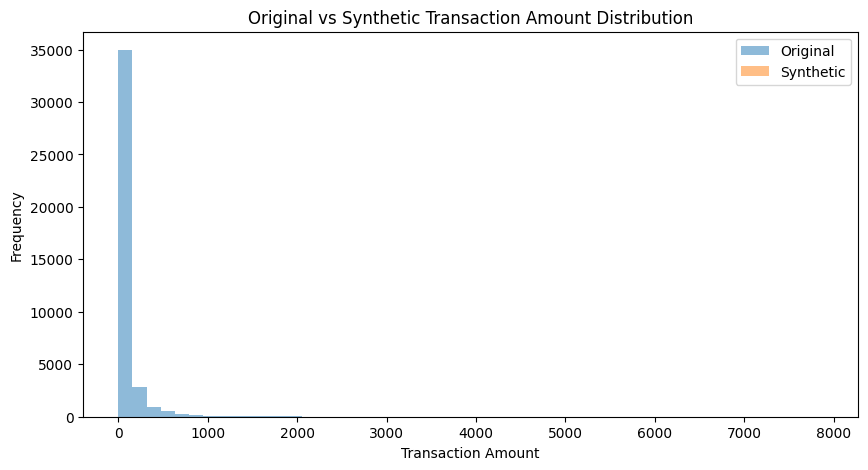

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    X["Amount"],
    bins=50,
    alpha=0.5,
    label="Original"
)

plt.hist(
    synthetic_df["Amount"],
    bins=50,
    alpha=0.5,
    label="Synthetic"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Original vs Synthetic Transaction Amount Distribution")
plt.legend()
plt.show()


In [32]:
original_corr = X.corr()
synthetic_corr = synthetic_df.corr()

correlation_difference = (
    original_corr - synthetic_corr
).abs().mean().mean()

print(
    "Average Correlation Difference:",
    correlation_difference
)

Average Correlation Difference: 0.2692580590817048


In [33]:
unique_rows = synthetic_df.drop_duplicates().shape[0]

diversity_percentage = (
    unique_rows / len(synthetic_df)
) * 100

print("Total synthetic transactions:", len(synthetic_df))
print("Unique synthetic transactions:", unique_rows)
print(f"Diversity: {diversity_percentage:.2f}%")

Total synthetic transactions: 1000
Unique synthetic transactions: 1000
Diversity: 100.00%


In [34]:
print("Original Amount Statistics")
print(X["Amount"].describe())

print("\nSynthetic Amount Statistics")
print(synthetic_df["Amount"].describe())

Original Amount Statistics
count    40136.000000
mean        87.831773
std        235.162467
min          0.000000
25%          7.400000
50%         23.700000
75%         79.252500
max       7879.420000
Name: Amount, dtype: float64

Synthetic Amount Statistics
count    1000.000000
mean       84.723091
std         0.574481
min        83.210686
25%        84.322699
50%        84.723694
75%        85.117950
max        86.561836
Name: Amount, dtype: float64


/tmp/ipykernel_3274/874430031.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


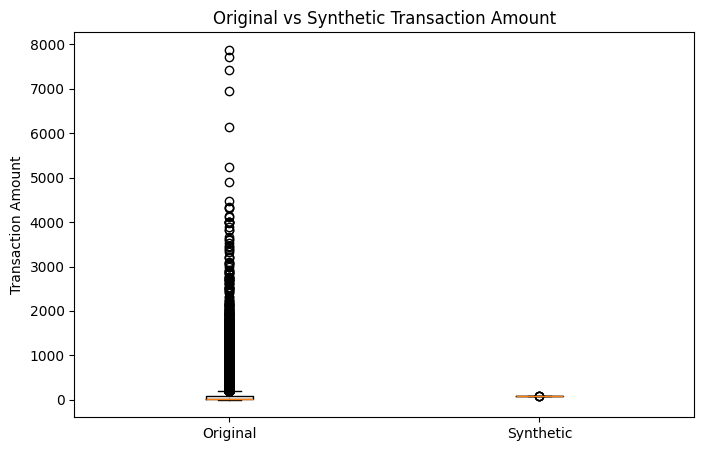

In [35]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        X["Amount"],
        synthetic_df["Amount"]
    ],
    labels=["Original", "Synthetic"]
)

plt.ylabel("Transaction Amount")
plt.title("Original vs Synthetic Transaction Amount")

plt.show()

In [36]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Number of synthetic transactions",
        "Number of unique transactions",
        "Diversity (%)",
        "Mean absolute difference",
        "Average correlation difference"
    ],
    "Value": [
        len(synthetic_df),
        unique_rows,
        diversity_percentage,
        mean_difference,
        correlation_difference
    ]
})

evaluation_results

,Metric,Value
0,Number of synthetic transactions,1000.000000
1,Number of unique transactions,1000.000000
2,Diversity (%),100.000000
3,Mean absolute difference,3.355115
4,Average correlation difference,0.269258


In [39]:
import numpy as np

In [40]:
print(
    "Missing values:",
    synthetic_df.isnull().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(
        synthetic_df.select_dtypes(include=np.number)
    ).sum().sum()
)

Missing values: 0
Infinite values: 0


In [41]:
# Mean Absolute Difference
mean_difference = (
    X.mean() - synthetic_df.mean()
).abs().mean()

# Correlation Difference
original_corr = X.corr()
synthetic_corr = synthetic_df.corr()

correlation_difference = (
    original_corr - synthetic_corr
).abs().mean().mean()

# Diversity
unique_rows = synthetic_df.drop_duplicates().shape[0]

diversity_percentage = (
    unique_rows / len(synthetic_df)
) * 100

print("========== EVALUATION RESULTS ==========")
print("Synthetic transactions :", len(synthetic_df))
print("Unique transactions    :", unique_rows)
print(f"Diversity              : {diversity_percentage:.2f}%")
print(f"Mean absolute difference: {mean_difference:.6f}")
print(f"Correlation difference  : {correlation_difference:.6f}")
print("Missing values          :", synthetic_df.isnull().sum().sum())
print("Infinite values         :", np.isinf(
    synthetic_df.select_dtypes(include=np.number)
).sum().sum())
print("=========================================")

========== EVALUATION RESULTS ==========
Synthetic transactions : 1000
Unique transactions    : 1000
Diversity              : 100.00%
Mean absolute difference: 3.355115
Correlation difference  : 0.269258
Missing values          : 0
Infinite values         : 0


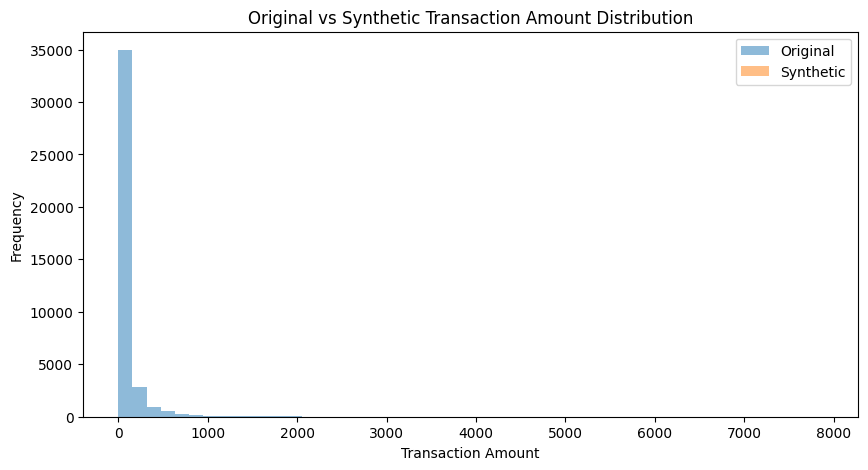

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    X["Amount"],
    bins=50,
    alpha=0.5,
    label="Original"
)

plt.hist(
    synthetic_df["Amount"],
    bins=50,
    alpha=0.5,
    label="Synthetic"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Original vs Synthetic Transaction Amount Distribution")
plt.legend()

plt.show()

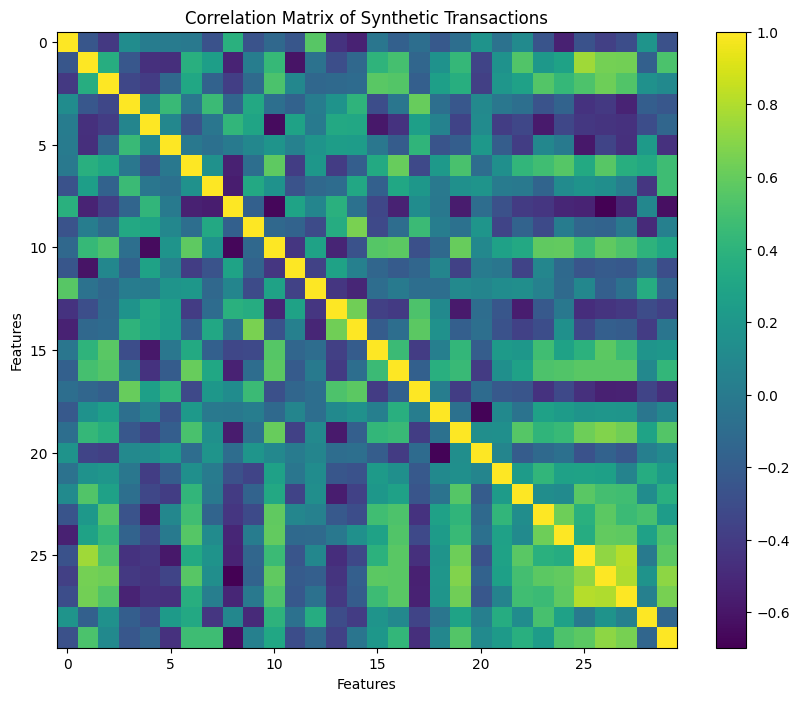

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(
    synthetic_df.corr(),
    aspect="auto"
)

plt.colorbar()

plt.title("Correlation Matrix of Synthetic Transactions")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [44]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Synthetic Transactions",
        "Unique Transactions",
        "Diversity (%)",
        "Mean Absolute Difference",
        "Correlation Difference",
        "Missing Values",
        "Infinite Values"
    ],
    "Value": [
        len(synthetic_df),
        unique_rows,
        diversity_percentage,
        mean_difference,
        correlation_difference,
        synthetic_df.isnull().sum().sum(),
        np.isinf(
            synthetic_df.select_dtypes(
                include=np.number
            )
        ).sum().sum()
    ]
})

evaluation_results

,Metric,Value
0,Synthetic Transactions,1000.000000
1,Unique Transactions,1000.000000
2,Diversity (%),100.000000
3,Mean Absolute Difference,3.355115
4,Correlation Difference,0.269258
5,Missing Values,0.000000
6,Infinite Values,0.000000


In [45]:
evaluation_results.to_csv(
    "synthetic_data_evaluation.csv",
    index=False
)

print("Evaluation table saved successfully!")

Evaluation table saved successfully!


In [46]:
synthetic_df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,25729.785156,-0.236737,0.033469,0.722685,0.199411,-0.227139,0.085387,-0.118473,0.060976,0.210413,...,0.047783,-0.031394,-0.116972,-0.043151,0.002810,0.129049,0.011087,0.000601,0.003921,85.397644
1,25803.650391,-0.239523,0.029597,0.730331,0.199445,-0.223947,0.086424,-0.119172,0.062954,0.210138,...,0.047190,-0.032527,-0.116409,-0.045095,0.000199,0.126212,0.009653,-0.001652,0.003763,84.456284
2,25779.214844,-0.242559,0.030688,0.728885,0.199638,-0.222038,0.086797,-0.118403,0.061992,0.211066,...,0.047969,-0.031770,-0.117256,-0.044198,0.002510,0.126096,0.009083,-0.001411,0.004321,84.111626
3,25739.521484,-0.237150,0.033402,0.725269,0.197818,-0.223633,0.086084,-0.121255,0.062285,0.204786,...,0.046315,-0.030928,-0.116201,-0.043156,0.001175,0.128240,0.010773,-0.001462,0.004807,84.105042
4,25748.388672,-0.236933,0.034157,0.726687,0.195357,-0.222469,0.086343,-0.119353,0.059924,0.206594,...,0.046812,-0.032533,-0.116223,-0.043356,0.002461,0.127840,0.011987,0.000104,0.004545,84.373184
5,25774.644531,-0.243875,0.028369,0.729374,0.200344,-0.220425,0.083175,-0.118218,0.063487,0.210530,...,0.047878,-0.033563,-0.117419,-0.044915,0.000774,0.126621,0.008007,-0.001556,0.004116,83.658585
6,25771.296875,-0.238082,0.032432,0.727479,0.198522,-0.224133,0.089049,-0.118645,0.057746,0.209667,...,0.048821,-0.029953,-0.116404,-0.043094,0.001574,0.127708,0.012239,-0.001001,0.004243,85.133080
7,25758.435547,-0.239620,0.029630,0.728520,0.202644,-0.223993,0.086148,-0.118607,0.062087,0.209079,...,0.047966,-0.033417,-0.116513,-0.044983,0.001150,0.127362,0.010269,-0.000850,0.003092,85.295845
8,25764.923828,-0.245255,0.032830,0.730923,0.201012,-0.219772,0.085498,-0.119329,0.062820,0.208850,...,0.046846,-0.032163,-0.117317,-0.044004,0.000917,0.126315,0.008149,-0.002663,0.004373,83.238617
9,25772.529297,-0.234244,0.033061,0.726369,0.199567,-0.227153,0.087108,-0.118646,0.061318,0.207326,...,0.046378,-0.031202,-0.115859,-0.045533,0.000819,0.128021,0.010632,-0.000881,0.003982,84.618027


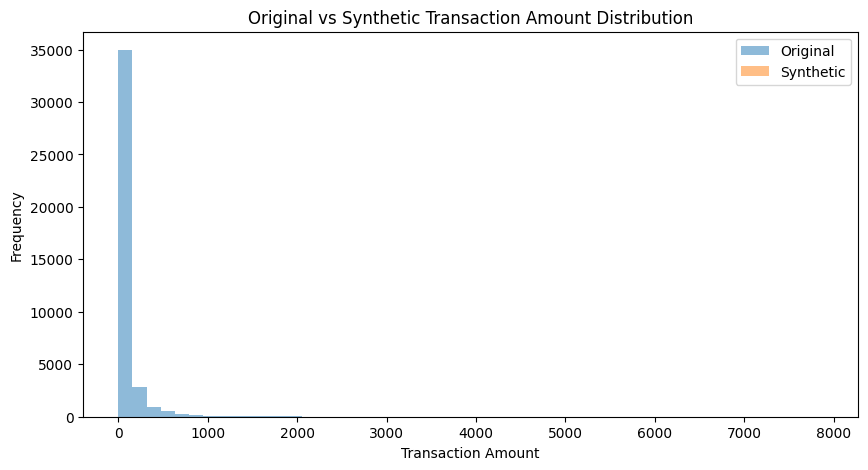

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(X["Amount"], bins=50, alpha=0.5, label="Original")
plt.hist(synthetic_df["Amount"], bins=50, alpha=0.5, label="Synthetic")

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Original vs Synthetic Transaction Amount Distribution")
plt.legend()

plt.show()

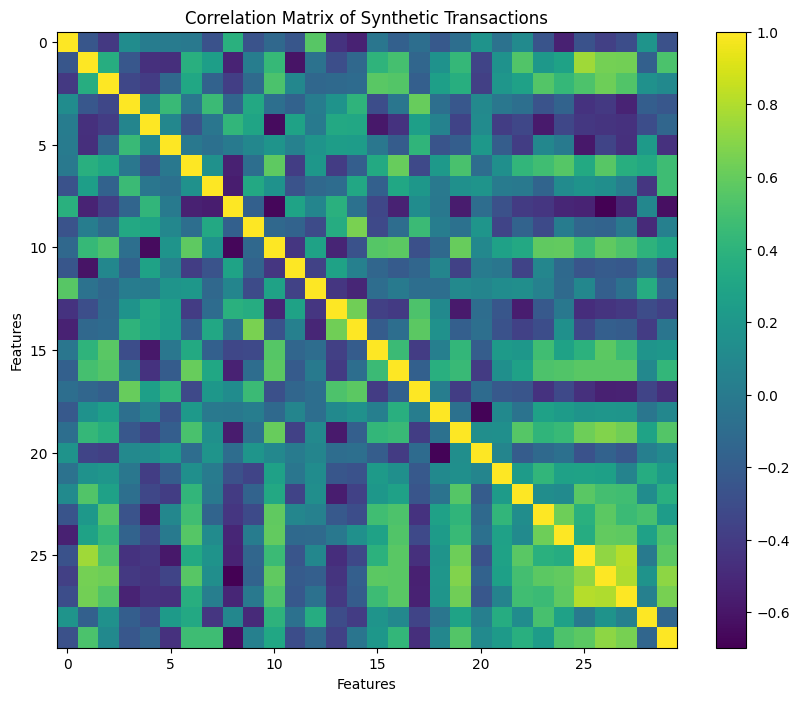

In [48]:
plt.figure(figsize=(10, 8))

plt.imshow(
    synthetic_df.corr(),
    aspect="auto"
)

plt.colorbar()

plt.title("Correlation Matrix of Synthetic Transactions")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [49]:
import os

print("Notebook/output files:")
print(os.listdir())

Notebook/output files:
['.config', 'credit-card-fraud-detection.csv', 'synthetic_data_evaluation.csv', 'synthetic_financial_transactions.csv', 'sample_data']
